# VaR と期待ショートフォールを、監査できるリスクテーブルとともに

誰にも再現できないリスク数値は、それ自体が負債です。このレシピでは、固定した株式帳簿に
ついて実際の日次データからヒストリカル VaR とパラメトリック VaR、そして期待ショートフォールを
計算し、Kupiec の POF 検定で VaR をバックテストします。そのうえで、多くのノートブックが
飛ばす部分をやります。日次のリスク指標をバージョン管理された h5i-db テーブルに、本番1日
につき1コミットで書き込むのです。「日付Xで報告した VaR は何で、どの入力から出たのか」が、
メールのやり取りではなくクエリになります。

働く機能はこうです。リターンのパイプラインには SQL のウィンドウ関数、監査証跡には追記のみの
コミット（`versions()` が、注記と実時刻のコミット時刻つきで日次実行をすべて見せます）、
そして日々の小さな append が溜まったあとテーブルを健全に保つ `compact()` です。

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import h5i_db
from h5i_db import col, count_star

import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_var"), create=True)

## 1. 実際の価格をバージョン管理テーブルへ

米国の流動性の高い30銘柄について、8年強の日次データです（キャッシュ済みの Yahoo データ）。
保存するのは `adj_close`、つまりトータルリターンに近い系列です。損益のリスクはこれで計算
すべきものです。一括の `append` 1回が、アトミックなコミット1回になります。

厳格さについて1つ知っておくとよい点があります。`sort_key=["ts", "symbol"]` の場合、`append` は
入力が*キー全体*で整列していることを求めます。日次パネルは同じタイムスタンプを30銘柄が共有
するので、`ts` だけのソートでは足りません。append の前に (ts, symbol) で並べてください。

In [2]:
real = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01")

schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("adj_close", pa.float64()),
    ]
)
db.create_table("prices", schema, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "prices",
    real.select(["ts", "symbol", "adj_close"]).sort_by([("ts", "ascending"), ("symbol", "ascending")]),
    note="vendor backfill 2018-2026",
)

db.table("prices").select(rows=count_star(), names=col("symbol").n_unique()).to_pandas()

,rows,names
0,64020,30


## 2. ポートフォリオの損益系列を SQL 1文で

帳簿は12銘柄固定のポートフォリオです（ウェイトの合計は1、想定元本1,000万ドル）。日次の単純
リターンは銘柄ごとの `lag()` ウィンドウから出し、ポートフォリオリターンはインラインの
`VALUES` によるウェイト関係とのジョインで加重和にします。すべてが時刻順ストレージの上を
流れます。ローリング分位点が本当に必要になるまで、pandas での整形は出てきません。

In [3]:
NOTIONAL = 10_000_000.0

WEIGHTS_SQL = """
    (VALUES ('AAPL', 0.10), ('MSFT', 0.10), ('NVDA', 0.08), ('AMZN', 0.08),
            ('GOOGL', 0.08), ('JPM', 0.10), ('XOM', 0.08), ('UNH', 0.08),
            ('PG', 0.08), ('KO', 0.06), ('CAT', 0.08), ('GS', 0.08)
    ) AS w(symbol, weight)
"""

# An inline VALUES relation has no builder verb, so this one stays SQL.
port = db.sql(
    f"""
    WITH rets AS (
        SELECT ts, symbol,
               adj_close / lag(adj_close) OVER (PARTITION BY symbol ORDER BY ts) - 1 AS ret
        FROM prices
    )
    SELECT r.ts, sum(r.ret * w.weight) AS port_ret, count(*) AS names
    FROM rets r
    JOIN {WEIGHTS_SQL} ON r.symbol = w.symbol
    WHERE r.ret IS NOT NULL
    GROUP BY r.ts
    ORDER BY r.ts
    """
).to_pandas()

# Keep only days where all 12 names have a return (guards against partial days).
port = port[port["names"] == 12].set_index("ts")
port["pnl"] = NOTIONAL * port["port_ret"]
print(f"{len(port):,} trading days, "
      f"ann. vol {port['port_ret'].std() * np.sqrt(252):.1%}, "
      f"worst day {port['pnl'].min():,.0f} USD")

2,133 trading days, ann. vol 20.9%, worst day -1,154,191 USD


## 3. ローリングのヒストリカル VaR／ES と、パラメトリックの2種類

どの指標も直近252日の窓を使い、**1日ずらします**。日 *t* について報告する VaR が使う情報は
*t−1* までです。このずらしこそが、リスクモデルと後知恵モデルを分けます。そして監査担当が
まさに尋ねてくる種類の細部でもあります。

- **ヒストリカル**: 窓の経験分位点。ES はその分位点より外側の裾の平均です。
- **パラメトリック正規**: ローリングの平均とボラに、正規分位点を掛けます。
- **パラメトリック Student-t**: 同じ形で、t 分位点（自由度は標準化した全サンプルで1回だけ
  推定）を単位分散にスケールし直したもの。安上がりのファットテール対策です。

In [4]:
from scipy import stats

r = port["port_ret"]
W = 252

def hist_var(x, q):
    return -np.quantile(x, q)

def hist_es(x, q):
    cut = np.quantile(x, q)
    return -x[x <= cut].mean()

roll = r.rolling(W)
port["var95"] = roll.apply(hist_var, args=(0.05,), raw=True).shift(1)
port["var99"] = roll.apply(hist_var, args=(0.01,), raw=True).shift(1)
port["es95"] = roll.apply(hist_es, args=(0.05,), raw=True).shift(1)
port["es99"] = roll.apply(hist_es, args=(0.01,), raw=True).shift(1)

mu, sd = roll.mean().shift(1), roll.std().shift(1)
port["var95_norm"] = -(mu + sd * stats.norm.ppf(0.05))

# Fit t df on the full standardized history, rescale to unit variance.
z = ((r - r.mean()) / r.std()).to_numpy()
nu = stats.t.fit(z, floc=0)[0]
t_scale = np.sqrt((nu - 2) / nu)
port["var95_t"] = -(mu + sd * stats.t.ppf(0.05, nu) * t_scale)

port[["var95", "es95", "var95_norm", "var95_t"]].dropna().tail(3).mul(NOTIONAL).round(0)

,var95,es95,var95_norm,var95_t
ts,,,,
2026-06-26 20:00:00+00:00,123777.0,166664.0,114636.0,93226.0
2026-06-29 20:00:00+00:00,123777.0,166664.0,114700.0,93303.0
2026-06-30 20:00:00+00:00,123777.0,166664.0,114576.0,93233.0


## 4. Kupiec の POF バックテスト: 95% は本当に95%か

実現損失が前日の VaR を超えた日を数え、Kupiec の失敗割合の尤度比検定（漸近的に自由度1の
カイ二乗）にかけます。うまく較正された95% VaR なら、breach はおよそ5%の日で起きるはずです。
帰無仮説が棄却されるなら、モデルのカバー率が間違っているということです。

In [5]:
def kupiec_pof(returns: pd.Series, var: pd.Series, p: float) -> dict:
    mask = var.notna()
    ret, v = returns[mask], var[mask]
    n = len(ret)
    x = int((ret < -v).sum())
    pi = x / n
    ll_null = (n - x) * np.log(1 - p) + x * np.log(p)
    ll_alt = ((n - x) * np.log(1 - pi) + x * np.log(pi)) if 0 < x < n else 0.0
    lr = -2 * (ll_null - ll_alt)
    return {"n_days": n, "breaches": x, "expected": round(n * p, 1),
            "breach_rate": round(pi, 4), "LR_pof": round(lr, 2),
            "p_value": round(float(stats.chi2.sf(lr, 1)), 4)}

backtest = pd.DataFrame(
    {
        "hist 95%": kupiec_pof(r, port["var95"], 0.05),
        "hist 99%": kupiec_pof(r, port["var99"], 0.01),
        "normal 95%": kupiec_pof(r, port["var95_norm"], 0.05),
        "t 95%": kupiec_pof(r, port["var95_t"], 0.05),
    }
).T
backtest

,n_days,breaches,expected,breach_rate,LR_pof,p_value
hist 95%,1881.0,98.0,94.1,0.0521,0.17,0.678
hist 99%,1881.0,33.0,18.8,0.0175,8.83,0.003
normal 95%,1881.0,98.0,94.1,0.0521,0.17,0.678
t 95%,1881.0,136.0,94.1,0.0723,17.41,0.000


表を正直に読むとこうなります。ヒストリカルと正規のモデルは95%でカバー率を保っていますが、
99%のヒストリカル VaR はカバー不足です（breach がボラのレジーム転換に固まって出るからで、
直近の経験分位点はそれを捉えるのが遅い。Kupiec が検定するのはカバー率だけで、独立性は見ません。
固まりを検出するなら Christoffersen の検定です）。そして「ファットテール対策」の罠にも注目
してください。単位分散にスケールし直した Student-t は、5%の水準では正規より*穏やかな*分位点に
なります。裾が逆転するのは1%あたりです。素朴に95%で t モデルに差し替えると保守的どころか
逆に緩くなり、検定はそれを捕まえます。

## 5. 監査証跡: バージョン管理された `risk_metrics` テーブル

本番でのパターンは、**履歴を1コミットで埋め、以後は EOD 実行ごとに1コミット**です。日々の
append はアトミックで注記を持つので、`versions()` が「どのリスク数値がどの日に公表され、
正確にはいつだったか」に答えます。実時刻のコミットタイムスタンプ付きで、追加のログ基盤は
要りません。ここでは直近60営業日を個別のコミットとして模擬します。

In [6]:
metrics = port.dropna(subset=["var95", "var99", "es95", "es99"])[
    ["pnl", "var95", "es95", "var99", "es99"]
].copy()
for c in ["var95", "es95", "var99", "es99"]:
    metrics[c] *= NOTIONAL

mschema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("pnl", pa.float64()),
        pa.field("var95", pa.float64()),
        pa.field("es95", pa.float64()),
        pa.field("var99", pa.float64()),
        pa.field("es99", pa.float64()),
    ]
)
db.create_table("risk_metrics", mschema, time_column="ts")

hist_part = metrics.iloc[:-60].reset_index()
db.append("risk_metrics", pa.Table.from_pandas(hist_part, schema=mschema, preserve_index=False),
          note="backfill through model go-live")

for day, row in metrics.iloc[-60:].iterrows():
    one = pa.Table.from_pandas(
        pd.DataFrame([row]).rename_axis("ts").reset_index(), schema=mschema, preserve_index=False
    )
    db.append("risk_metrics", one, note=f"eod risk {day.date()}")

[
    {k: v.get(k) for k in ("sequence", "op", "rows", "note")}
    for v in db.versions("risk_metrics")[-4:]
]

[{'sequence': 58, 'op': 'append', 'rows': 1878, 'note': 'eod risk 2026-06-25'},
 {'sequence': 59, 'op': 'append', 'rows': 1879, 'note': 'eod risk 2026-06-26'},
 {'sequence': 60, 'op': 'append', 'rows': 1880, 'note': 'eod risk 2026-06-29'},
 {'sequence': 61, 'op': 'append', 'rows': 1881, 'note': 'eod risk 2026-06-30'}]

60個の小さなコミットは、60個の小さな Parquet セグメントでもあります。`compact()` がそれを
効率のよいセグメントに併合します。それ自体が監査対象のコミットになるので、メンテナンスまで
履歴に現れます。

In [7]:
before = db.versions("risk_metrics")[-1]
compacted = db.compact("risk_metrics", note="post-EOD-loop compaction")
print(f"segments: {before['segments']} -> {compacted['segments_total']}, "
      f"op={compacted['op']}, sequence={compacted['sequence']}")

segments: 61 -> 1, op=compact, sequence=62


リスクテーブルは他と同じようにクエリできます。ここでは直近2年の breach の日を、そのまま
SQL で取り出します。

In [8]:
(
    db.table("risk_metrics")
    .filter(col("pnl") < -col("var95"), col("ts") >= "2024-07-01T00:00:00Z")
    .select(
        "ts",
        pnl=col("pnl").round(),
        var95_floor=(-col("var95")).round(),
        var99_floor=(-col("var99")).round(),
    )
    .sort("ts", descending=True)
    .limit(8)
    .to_pandas()
)

,ts,pnl,var95_floor,var99_floor
0,2026-06-17 20:00:00+00:00,-120366.0,-115987.0,-184759.0
1,2026-06-10 20:00:00+00:00,-148196.0,-104481.0,-184759.0
2,2026-06-05 20:00:00+00:00,-138137.0,-102827.0,-184759.0
3,2026-03-27 20:00:00+00:00,-157587.0,-147858.0,-274463.0
4,2026-03-26 20:00:00+00:00,-147359.0,-147281.0,-274463.0
5,2026-03-12 20:00:00+00:00,-151007.0,-138104.0,-274463.0
6,2026-02-12 20:00:00+00:00,-168461.0,-158913.0,-281868.0
7,2026-02-05 20:00:00+00:00,-171680.0,-147281.0,-281868.0


## 6. VaR のバンドに対する損益と、印を付けた breach

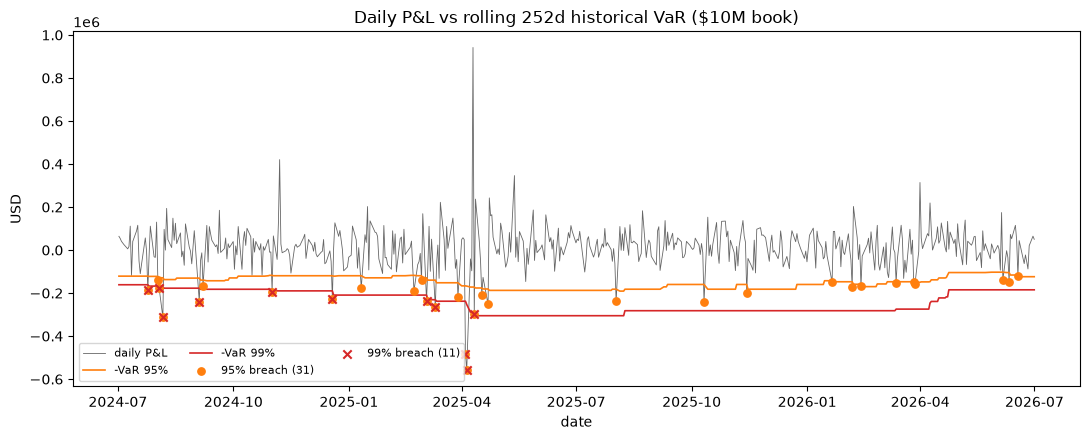

In [9]:
import matplotlib.pyplot as plt

plot_df = metrics.loc["2024-07-01":]
breach95 = plot_df[plot_df["pnl"] < -plot_df["var95"]]
breach99 = plot_df[plot_df["pnl"] < -plot_df["var99"]]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(plot_df.index, plot_df["pnl"], lw=0.6, color="0.4", label="daily P&L")
ax.plot(plot_df.index, -plot_df["var95"], lw=1.2, color="tab:orange", label="-VaR 95%")
ax.plot(plot_df.index, -plot_df["var99"], lw=1.2, color="tab:red", label="-VaR 99%")
ax.scatter(breach95.index, breach95["pnl"], s=28, color="tab:orange", zorder=3,
           label=f"95% breach ({len(breach95)})")
ax.scatter(breach99.index, breach99["pnl"], s=36, color="tab:red", marker="x", zorder=4,
           label=f"99% breach ({len(breach99)})")
ax.set_title("Daily P&L vs rolling 252d historical VaR ($10M book)")
ax.set_xlabel("date")
ax.set_ylabel("USD")
ax.legend(loc="lower left", ncols=3, fontsize=8)
fig.tight_layout()

## まとめ

- リターンのパイプライン全体――銘柄ごとの `lag()` リターン、加重ポートフォリオの集約――は、
  時刻順ストレージの上の SQL 1文です。pandas が出てくるのはローリング分位点のときだけです。
- VaR の窓は1日ずらしてください。そうすれば Kupiec の POF 検定がカバー率の成否を正直に
  教えてくれます。99%における正規モデルのファットテールの失敗は、言い伝えではなく数字に
  出ます。
- `risk_metrics` は*ただで手に入る監査証跡*です。EOD 実行ごとに注記付きの append を1回打つ
  だけで、`versions()` が過去に報告したすべてのリスク数値の公表時刻を正確に返します。追加の
  ログシステムは要りません。
- 日々の小さなコミットが多いのは構いません。ときどき `compact()` を走らせてください。それ
  自体がバージョンの付いた注記付きコミットです。

In [10]:
db.close()